In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df= pd.read_csv('insurance.csv')
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


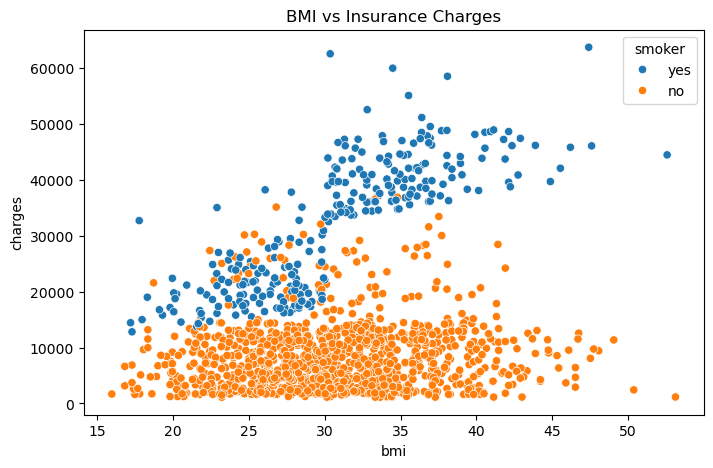

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Insurance Charges')
plt.show()

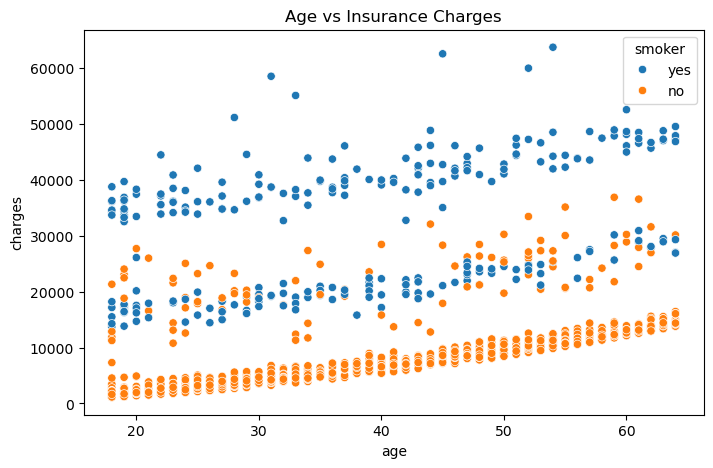

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Age vs Insurance Charges')
plt.show()

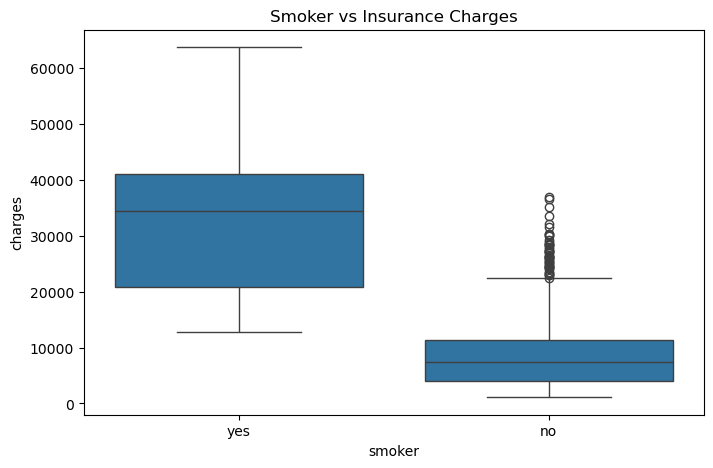

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Smoker vs Insurance Charges')
plt.show()

In [8]:

df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})
df['region'] = df['region'].map({'northeast':0, 'northwest':1, 'southeast':2, 'southwest':3})

# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

print("Data prepared successfully!")

Data prepared successfully!


In [9]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 4186.51
RMSE: 5799.59


## Conclusion
- Smoking status has the highest impact on insurance charges
- Higher BMI leads to higher charges especially for smokers
- Age also positively correlates with insurance charges
- Linear Regression model successfully predicts insurance costs